# Interacting with CLIP

This is a self-contained notebook that shows how to download and run CLIP models, calculate the similarity between arbitrary image and text inputs, and perform zero-shot image classifications.

# Preparation for Colab

Make sure you're running a GPU runtime; if not, select "GPU" as the hardware accelerator in Runtime > Change Runtime Type in the menu. The next cells will install the `clip` package and its dependencies, and check if PyTorch 1.7.1 or later is installed.

In [ ]:
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-2rykbz9s
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-2rykbz9s
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369489 sha256=b26afafa447090dcce0d9cd5cf5540291b96c8a19c458071a6e079c216313b4b
  Stored in directory: /tmp/pip-ephem-wheel-cache-xxgtnwn9/wheels/da/2b/4c/d6691fa9597aac8bb85d2ac13b112deb897d5b50f5ad9a37e4
Successfully built clip


In [ ]:
import numpy as np
import torch
from pkg_resources import packaging

print("Torch version:", torch.__version__)


Torch version: 2.5.1+cu121


<ipython-input-2-cc4b7f78b657>:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import packaging


# Loading the model

`clip.available_models()` will list the names of available CLIP models.

In [ ]:
import clip

clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [ ]:
model, preprocess = clip.load("ViT-B/32")
model.cuda().eval()
input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Input resolution:", input_resolution)
print("Context length:", context_length)
print("Vocab size:", vocab_size)

100%|███████████████████████████████████████| 338M/338M [00:09<00:00, 38.8MiB/s]


Model parameters: 151,277,313
Input resolution: 224
Context length: 77
Vocab size: 49408


# Image Preprocessing

We resize the input images and center-crop them to conform with the image resolution that the model expects. Before doing so, we will normalize the pixel intensity using the dataset mean and standard deviation.

The second return value from `clip.load()` contains a torchvision `Transform` that performs this preprocessing.



In [ ]:
preprocess

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7c73fafc8b80>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

# Text Preprocessing

We use a case-insensitive tokenizer, which can be invoked using `clip.tokenize()`. By default, the outputs are padded to become 77 tokens long, which is what the CLIP models expects.

In [ ]:
# clip.tokenize("Hello World!")

tensor([[49406,  3306,  1002,   256, 49407,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]], dtype=torch.int32)

# Setting up input images and texts

We are going to feed 8 example images and their textual descriptions to the model, and compare the similarity between the corresponding features.

The tokenizer is case-insensitive, and we can freely give any suitable textual descriptions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import skimage
import IPython.display
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

from collections import OrderedDict
import torch

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
file_path = '/content/drive/MyDrive/text_data.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    print(f"Error: File not found at {file_path}. Please check the file path and ensure the file exists.")
    # Handle the error appropriately, e.g., exit the script or use a default file
# images in skimage to use and their textual descriptions
# descriptions = {
#     "OSHA_1": "Falls cause one of every three construction worker deaths",
#     "OSHA_2": "But these deaths can be prevented",
#     "OSHA_3": "Employers have a responsibility to provide a safe workplace",
#     "OSHA_4": "All scenes are based on true stories",
#     "OSHA_5": "Two workers were framing the walls.",
#     "OSHA_6": "They were working on the second floor near an open stairwell",
#     "OSHA_7": "There was no guardrail or floor cover, and the workers were not wearing personal fall protection.",
#     "OSHA_8": "the workers raised it and moved forward to put it into place",
#     "OSHA_9": "one of the workers stepped towards the unguarded stairwell to hold the side of the wall section",
#     "OSHA_10": "He fell down the unguarded stairwell opening",
#     "OSHA_11": "He fell 20 feet and landed on the concrete basement floor",
#     "OSHA_12": "He died from fatal head and internal injuries",
#     "OSHA_13": "Now, the stairwell is protected by a guardrail as required by OSHA.",
#     "OSHA_14": "As before, the workers are moving forward to install the completed wall section",
#     "OSHA_15": "This time, as the worker steps toward the stairwell",
#     "OSHA_16": "the guardrail stops him",
#     "OSHA_17": "Another way to protect workers is by putting a proper cover over the stairwell opening.",
#     "OSHA_18": "The cover must be secure",
#     "OSHA_19": "This example shows the importance of following OSHA's fall protection standards.",
#     "OSHA_20": "If you would like more information, contact OSHA at www.osha.gov or 1-800-321-OSHA that's 1-800-321-6742."
# }

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
descriptions = df.set_index('image')['Expected caption'].to_dict()

In [ ]:
descriptions

{'OSHA_1': 'fall protection for floor openings',
 'OSHA_2': 'fall protection for unguarded skylight',
 'OSHA_3': 'fall protection for fixed scaffolds',
 'OSHA_4': 'fall protection for unsecured bridge decking',
 'OSHA_5': 'fall protection for reroofing',
 'OSHA_6': 'fall protection for leading Edge Work',
 'OSHA_7': 'secured area for swinging cranes',
 'OSHA_8': 'carbon monoxide poisoning',
 'OSHA_9': 'trench cave-in',
 'OSHA_10': 'protecting workers from overhead powerline hazards'}

In [ ]:
os.listdir('/content/drive/MyDrive/ASCE paper/OSHA prevention')

['OSHA_1.jpeg',
 'OSHA_2.jpeg',
 'OSHA_3.jpeg',
 'OSHA_4.png',
 'OSHA_5.jpeg',
 'OSHA_6.jpeg',
 'OSHA_7.jpeg',
 'OSHA_8.jpeg',
 'OSHA_9.jpeg',
 'OSHA_10.jpeg']

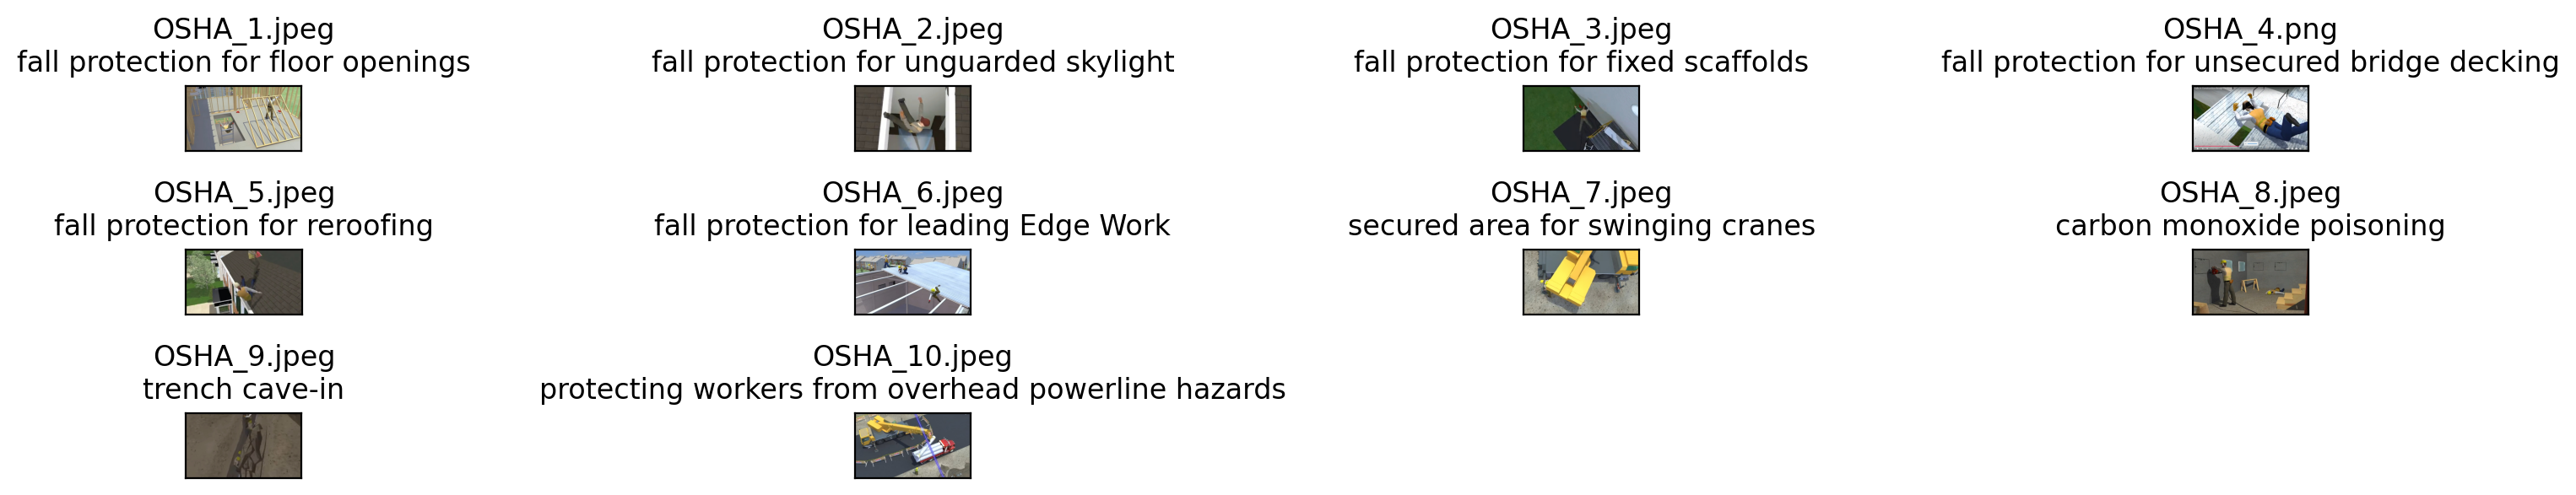

In [ ]:
original_images = []
images = []
texts = []
image_path = '/content/drive/MyDrive/ASCE paper/OSHA prevention/'
plt.figure(figsize=(16, 5))

for filename in [filename for filename in os.listdir(image_path) if filename.endswith(".png") or filename.endswith(".jpg") or filename.endswith(".jpeg")]:
    name = os.path.splitext(filename)[0]
    if name not in descriptions:
        continue

    image = Image.open(os.path.join(image_path, filename)).convert("RGB")

    plt.subplot(5, 4, len(images) + 1)
    plt.imshow(image)
    plt.title(f"{filename}\n{descriptions[name]}")
    plt.xticks([])
    plt.yticks([])

    original_images.append(image)
    images.append(preprocess(image))
    texts.append(descriptions[name])

plt.tight_layout()


## Building features

We normalize the images, tokenize each text input, and run the forward pass of the model to get the image and text features.

In [ ]:
image_input = torch.tensor(np.stack(images)).cuda()
text_tokens = clip.tokenize(["This is " + desc for desc in texts]).cuda()

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    text_features = model.encode_text(text_tokens).float()

## Calculating cosine similarity

We normalize the features and calculate the dot product of each pair.

In [ ]:
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
similarity = text_features.cpu().numpy() @ image_features.cpu().numpy().T

Text(0.5, 1.0, 'Cosine similarity between text and image features')

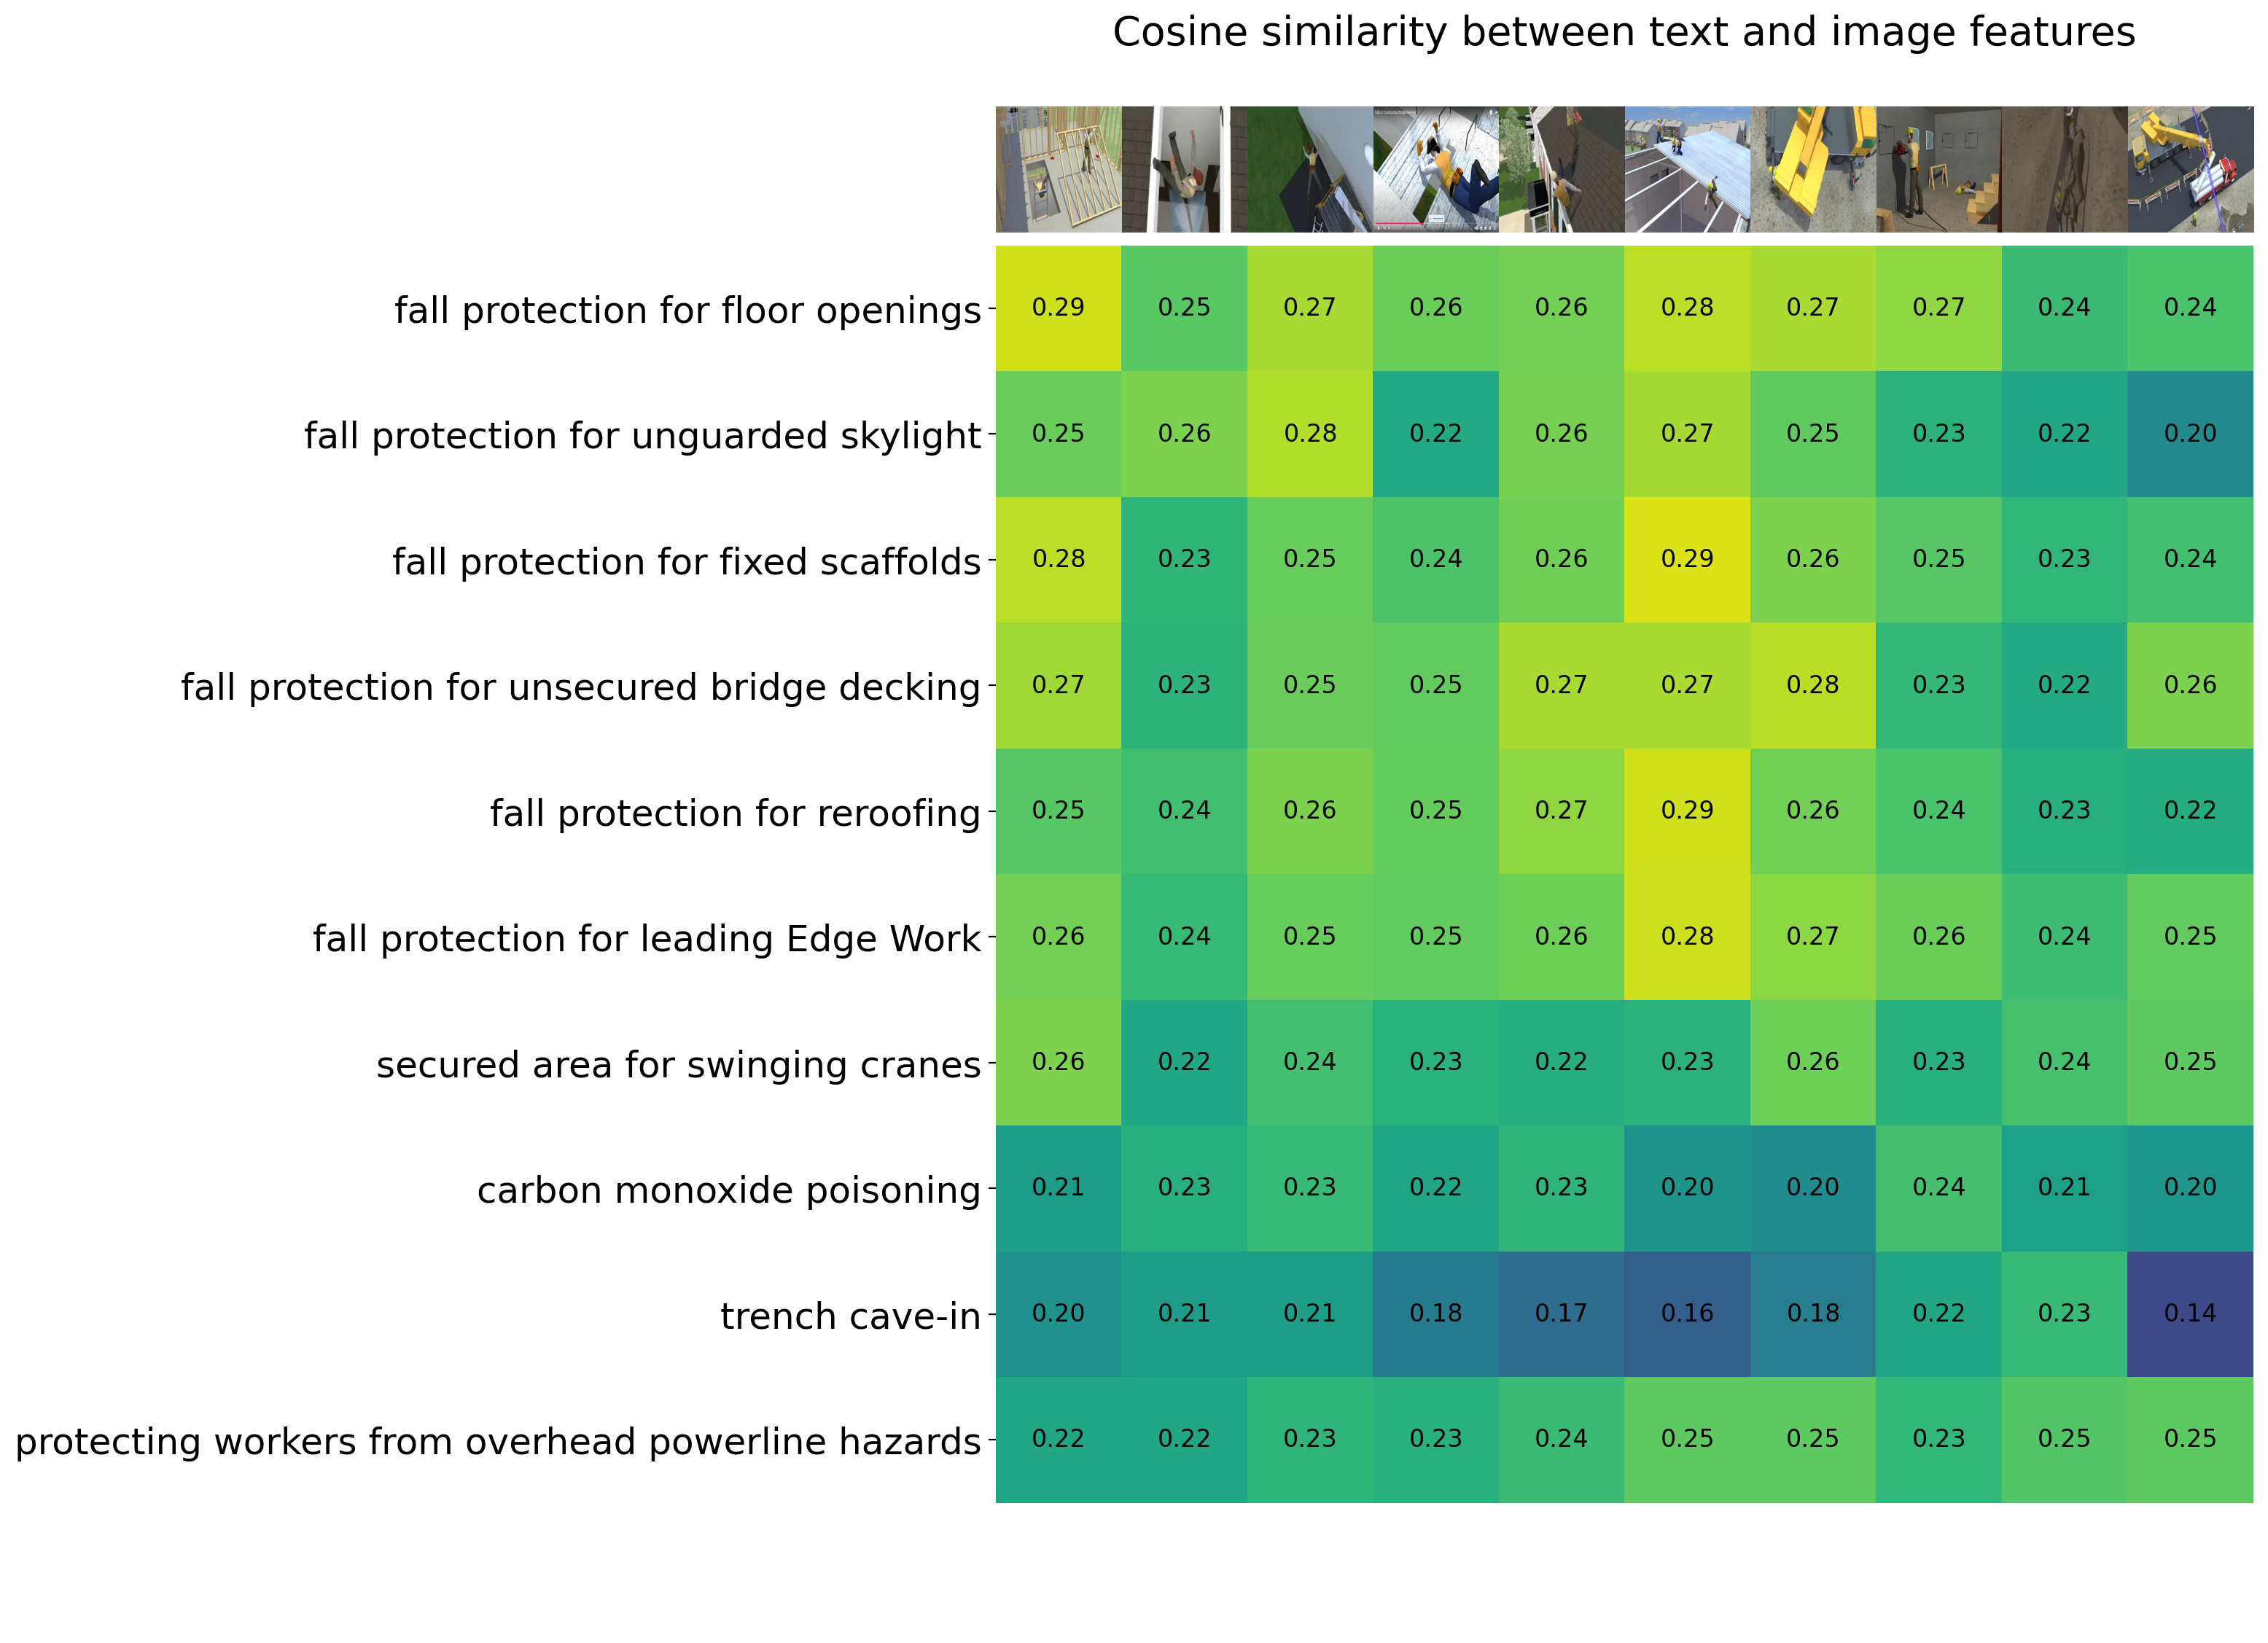

In [ ]:
count = len(descriptions)

plt.figure(figsize=(20, 14))
plt.imshow(similarity, vmin=0.1, vmax=0.3)
# plt.colorbar()
plt.yticks(range(count), texts, fontsize=18)
plt.xticks([])
for i, image in enumerate(original_images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
  plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)

# Zero-Shot Image Classification

You can classify images using the cosine similarity (times 100) as the logits to the softmax operation.

In [ ]:
# from torchvision.datasets import CIFAR100

# cifar100 = CIFAR100(os.path.expanduser("~/.cache"), transform=preprocess, download=True)

100%|██████████| 169M/169M [00:04<00:00, 41.5MB/s]


Extracting /root/.cache/cifar-100-python.tar.gz to /root/.cache


In [ ]:
hazard_list= ['Workers without helmets',
'Open floor edges without guardrails',
'Unsecured scaffolding',
'Faulty electrical wiring',
'Tools scattered around walkways',
'Unprotected floor openings',
'Improperly stored materials',
'Workers without fall protection near edges',
'Overloaded scaffolding',
'Blocked emergency exits',
'Unsecured ladders',
'Workers without high-visibility clothing',
'Improperly grounded electrical equipment',
'Spills creating slip hazards',
'Exposed sharp objects or rebar without caps',
'Improper use of machinery without training',
'Workers without gloves handling hazardous materials',
'Excessive noise levels without hearing protection',
'Damaged power tools in use',
'Missing fire extinguishers on-site',
'Overhead work without proper barricades below',
'Improper stacking of materials causing collapse risk',
'Exposed live electrical wires',
'Lack of proper ventilation in confined spaces',
'Workers not wearing safety goggles when cutting materials',
'Unsecured construction vehicles on slopes',
'Operating heavy equipment without spotters',
'Improper chemical storage',
'Absence of emergency eyewash stations',
'Unmarked hazardous areas',
'Compressed gas cylinders not secured upright',
'Improper lifting techniques causing strain injuries',
'Workers without respiratory protection in dusty environments',
'Inadequate lighting in work areas',
'Overhead crane loads without proper rigging',
'Use of defective harnesses or lanyards',
'Improperly installed temporary walkways',
'Workers near rotating machinery without proper guards',
'Failure to follow lockout/tagout procedures',
'Improper disposal of hazardous waste',
'Working near trenches without proper shoring',
'Collapsed trenches due to lack of support',
'Use of non-load-rated lifting equipment',
'Absence of first aid kits on-site',
'Inadequate training for equipment operators',
'Improper use of power cords creating trip hazards',
'Leaking fuel or oil from machinery',
'Workers wearing inappropriate footwear',
'Welding without face shields',
'Improper ventilation during painting operations',
'Absence of safety signage',
'Working in extreme temperatures without precautions',
'Improper handling of flammable materials',
'Unmarked crane swing radius',
'Workers using mobile phones in hazardous areas',
'Excessive dust without control measures',
'Loose or uneven flooring on walkways',
'Improper use of hand tools',
'Workers lifting loads beyond capacity',
'Lack of barricades around excavation sites',
'Failure to perform routine equipment inspections',
'Unattended running equipment',
'Improper maintenance of safety gear',
'Working on wet surfaces without slip-resistant shoes',
'Improper disposal of sharp objects',
'Absence of weather-related precautions',
'Improper mixing of chemicals without safety precautions',
'Lack of traffic control measures near site entrances',
'Use of machinery near power lines without proper clearance',
'Improperly installed temporary electrical wiring',
'Unsecured temporary structures during strong winds',
'Failure to report near-miss incidents',
'Workers without adequate hydration in hot environments',
'Improperly installed guardrails',
'Workers not following ladder safety rules',
'Incomplete site safety briefings',
'Failure to enforce speed limits for vehicles on-site',
'No safety harnesses on aerial lifts',
'Operating cranes without proper certifications',
'Overuse of extension cords on circuits',
'Improper barricades for pedestrian areas',
'Workers smoking in flammable areas',
'Improperly labeled hazardous substances',
'Failure to secure tools during overhead work',
'Ignoring weather alerts for high winds or storms',
'Improper drainage causing water pooling',
'Using tools beyond their rated capacity',
'Failure to document and address safety violations',
'Lack of routine hazard assessments',
'Workers wearing loose clothing near machinery',
'No backup alarms on construction vehicles',
'Failure to separate pedestrian and vehicle traffic',
'Inadequate edge protection on roof work',
'Improper storage of explosive materials',
'Failure to use personal protective equipment when required',
'Lack of fall arrest systems on elevated work platforms',
'Improper use of hoists or pulleys',
'Failure to clear snow and ice from work areas']

In [ ]:
text_descriptions = [f"This is an image of {label}" for label in hazard_list]
text_tokens = clip.tokenize(text_descriptions).cuda()

In [ ]:
text_descriptions

['This is an image of Workers without helmets',
 'This is an image of Open floor edges without guardrails',
 'This is an image of Unsecured scaffolding',
 'This is an image of Faulty electrical wiring',
 'This is an image of Tools scattered around walkways',
 'This is an image of Unprotected floor openings',
 'This is an image of Improperly stored materials',
 'This is an image of Workers without fall protection near edges',
 'This is an image of Overloaded scaffolding',
 'This is an image of Blocked emergency exits',
 'This is an image of Unsecured ladders',
 'This is an image of Workers without high-visibility clothing',
 'This is an image of Improperly grounded electrical equipment',
 'This is an image of Spills creating slip hazards',
 'This is an image of Exposed sharp objects or rebar without caps',
 'This is an image of Improper use of machinery without training',
 'This is an image of Workers without gloves handling hazardous materials',
 'This is an image of Excessive noise le

This code snippet is used for image-to-text similarity classification using a model (likely CLIP or a similar vision-language model). The goal is to determine which textual descriptions best match each image

Assume you have the following setup:

3 images
10 textual descriptions
After running this code:

text_probs will be a tensor of shape (3, 10), where each row represents the probability distribution of the 10 text descriptions for a single image.
top_probs will be of shape (3, 5), showing the top 5 probabilities for each image.
top_labels will be of shape (3, 5), showing the indices of the top 5 descriptions.

In [ ]:
with torch.no_grad():
    text_features = model.encode_text(text_tokens).float()
    text_features /= text_features.norm(dim=-1, keepdim=True)

text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
top_probs, top_labels = text_probs.cpu().topk(3, dim=-1)

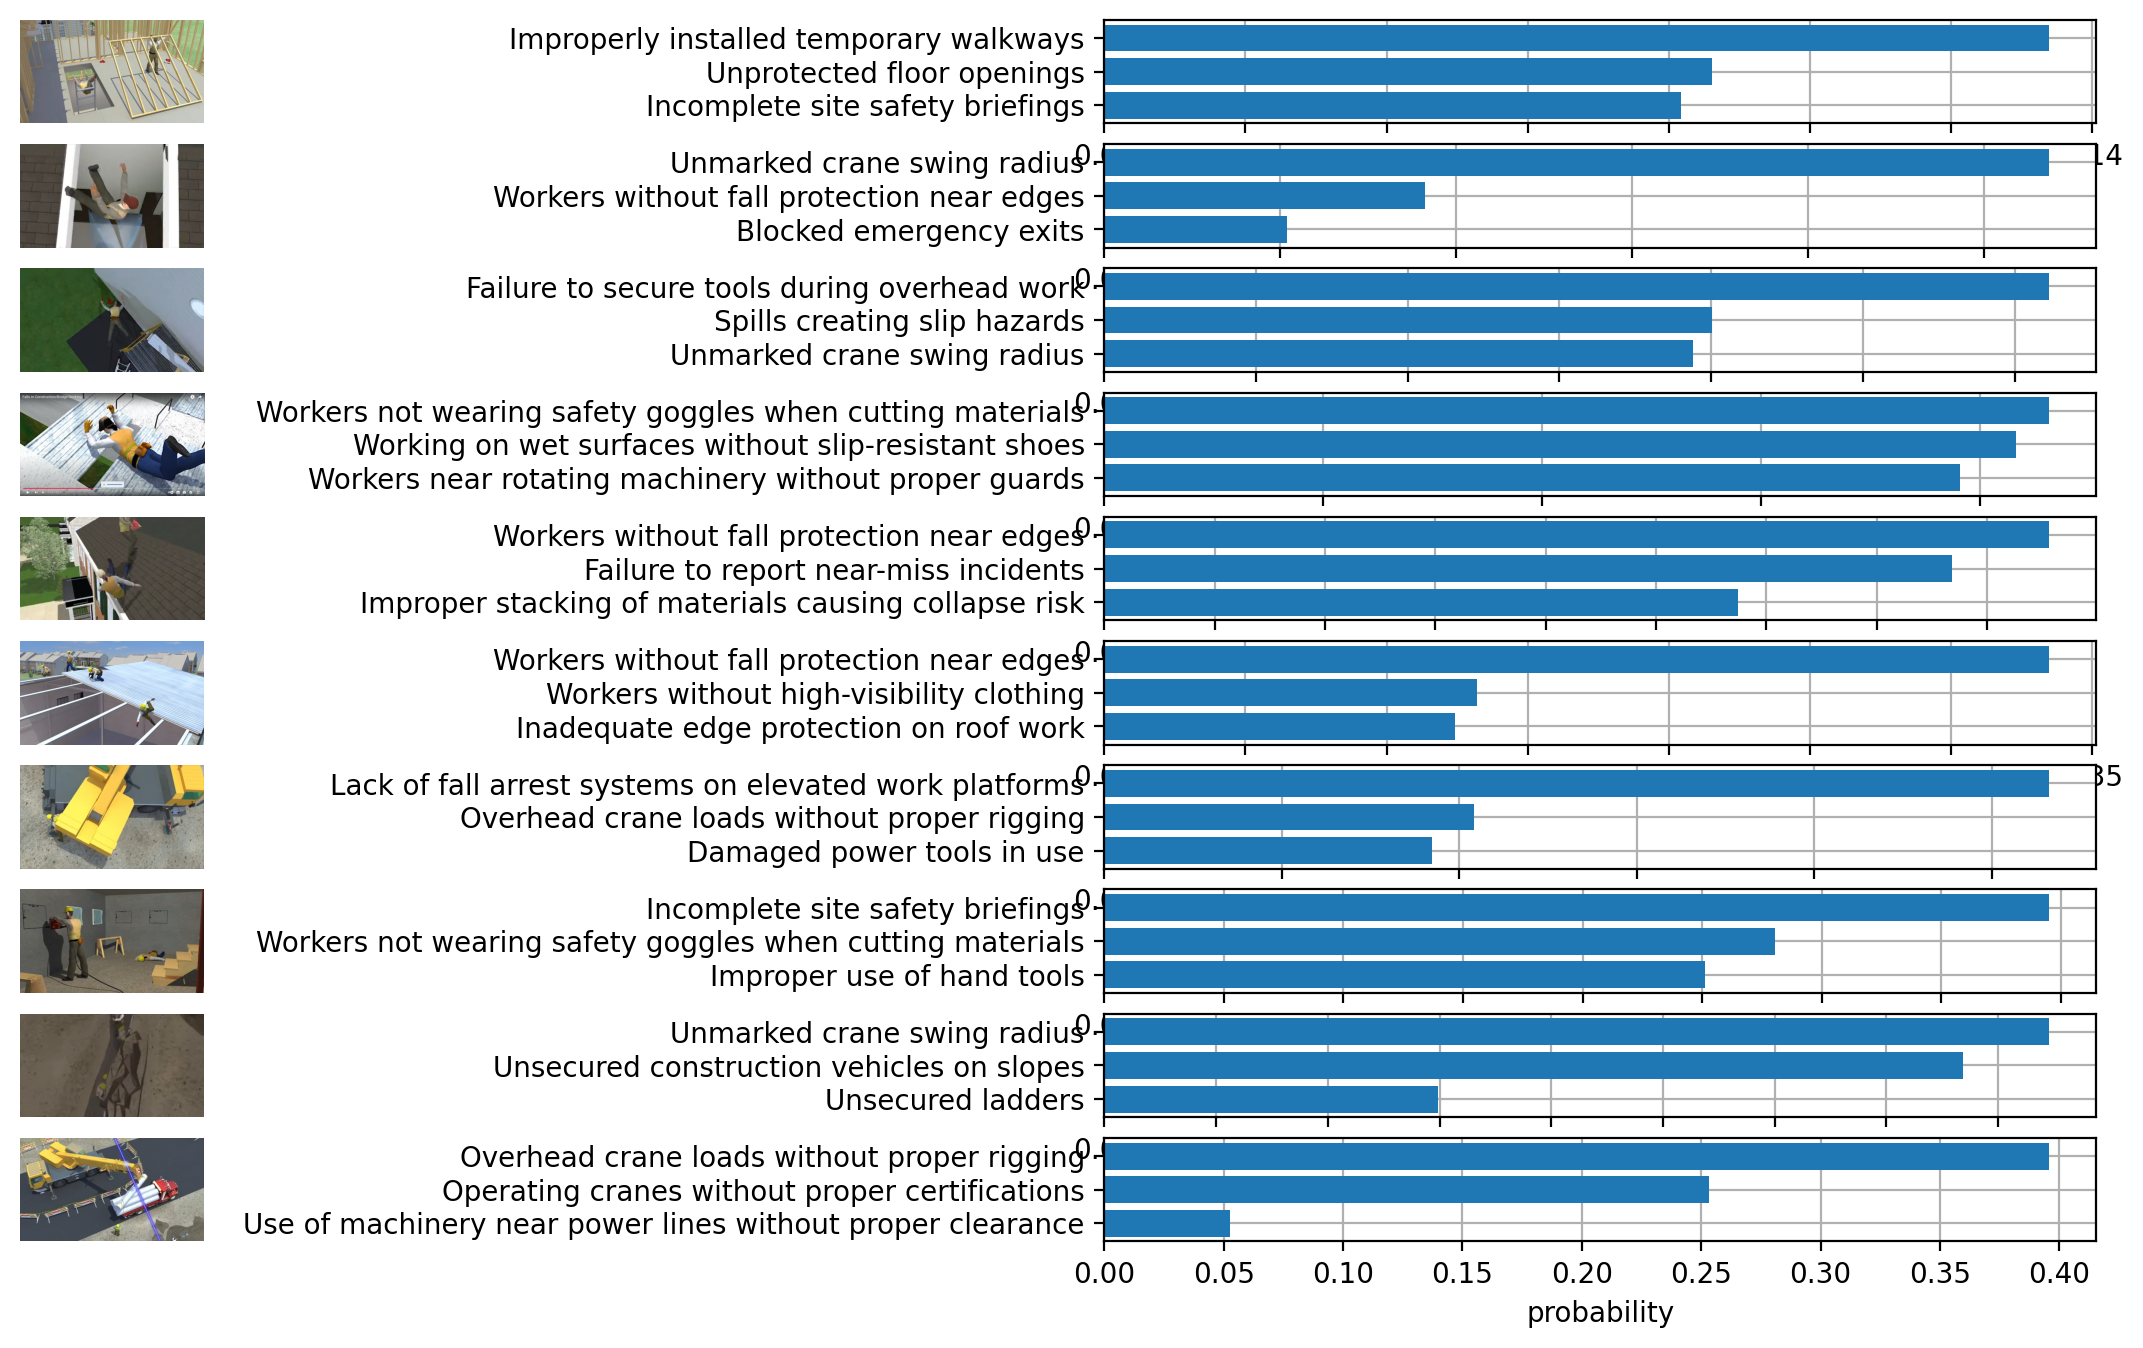

In [ ]:

plt.figure(figsize=(16, 16))

for i, image in enumerate(original_images):
    plt.subplot(20, 2, 2 * i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(20, 2, 2 * i + 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs[i])
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [hazard_list[index] for index in top_labels[i].numpy()])
    plt.xlabel("probability")

plt.subplots_adjust(wspace=0.5)
plt.show()